
# **<font color='purple'> `Part 4: Deep Learning Classifiers`</font>**
***
**Student**


|         Full name         |   Username  |         Email         |
|---------------------------|-------------|-----------------------|
| Emmanuel Nyandu Kagarabi  | emmanuelnk  | emmanuelnk@aims.ac.za |

<font color='teal'>`AI-Powered Classification and Early Detection of Dengue Lineages for a Timely Public Health Response`</font>

# `0. IMPORTS`

In [ ]:
# Installations
!pip install imbalanced-learn
!pip install scikit-learn
!pip install keras-self-attention
# Clean installation outputs`
from IPython.display import clear_output
clear_output()

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input, Conv1D,Conv2D,MaxPooling1D,MaxPooling2D, Flatten,BatchNormalization,GlobalMaxPooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, AdamW
from tensorflow.keras.preprocessing.sequence import pad_sequences
from collections import Counter
import re
import os
import sys
import random
import zipfile
import sklearn
import imblearn
import optuna
import Bio
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score, confusion_matrix,
                             roc_curve, auc, classification_report, precision_recall_curve, average_precision_score)
#from sklearn.utils.multiclass import unique_label
from scipy.stats import entropy
from datetime import datetime
from random import shuffle
%matplotlib inline
import time
from keras_self_attention import SeqSelfAttention #Import the SeqSelfAttention layer
# Random Sampling
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from itertools import cycle
import json
import warnings
warnings.filterwarnings("ignore")

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TensorFlow warnings
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
from IPython.display import clear_output
clear_output()
now = datetime.now()
now.strftime("%H:%M:%S")

'12:18:45'

In [ ]:
# Check versions
print(f"Python version: {sys.version}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"TensorFlow-Keras version: {tf.keras.__version__}")
print(f"imbalanced-learn version: {imblearn.__version__}")
print(f"Optuna version: {optuna.__version__}")
print(f"Biopython version: {Bio.__version__}")

Python version: 3.10.12 (main, Sep 11 2024, 15:47:36) [GCC 11.4.0]
Scikit-learn version: 1.4.2
TensorFlow-Keras version: 3.4.1
imbalanced-learn version: 0.12.3
Optuna version: 4.0.0
Biopython version: 1.84


# `1. Dataset`

In [ ]:
df = pd.read_csv('/content/FINAL_DATASET/MERGED/df_hierarchical.csv')
df.head()

,Sequence,Lineage,Hierarchy,Lineage_Splitted,Length,Serotype,Collection date,Submission date,Location
0,TAGTCTACGTGGACCGACAAGAACAGTTTCGAATCGGAAGCTTGCT...,1I_K.2,"['1', 'I', 'K', '2']",1_I_K_2,10652,DENV1,2022-05-24,2023-11-16,Asia / Indonesia / Bali
1,CGTGGACCGACAAAGACAGATTCTTTGAGGAAGCTAAGCTTAACGT...,2II_F.1.2,"['2', 'II', 'F', '1.2']",2_II_F_1.2,10490,DENV2,2024-03-22,2024-05-24,South America / Ecuador / Loja
2,CGACTCGGAAGCTTGCTTAACGTAGTGCTAACAGTTTTTATTAGAG...,3III_B.3,"['3', 'III', 'B', '3']",3_III_B_3,10461,DENV3,2023-06-08,2023-10-10,North America / USA / Florida
3,CACAGTTGGCGAAGAGATTCTCAAAAGGATTGCTGAACGGCCAGGG...,3III_C.2,"['3', 'III', 'C', '2']",3_III_C_2,10393,DENV3,2022-09-27,2023-05-20,North America / Mexico / Veracruz
4,TTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACAGTTTTTTATT...,1V_D.1,"['1', 'V', 'D', '1']",1_V_D_1,10087,DENV1,2020-12-18,2023-04-13,North America / USA / Florida


In [ ]:
# Is the  lenth constant?
df['Length'].describe().T

,Length
count,3527.000000
mean,10514.581514
std,172.945523
min,9685.000000
25%,10410.000000
50%,10567.000000
75%,10654.000000
max,10821.000000


In [ ]:
# Infos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3527 entries, 0 to 3526
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Sequence          3527 non-null   object
 1   Lineage           3527 non-null   object
 2   Hierarchy         3527 non-null   object
 3   Lineage_Splitted  3527 non-null   object
 4   Length            3527 non-null   int64 
 5   Serotype          3527 non-null   object
 6   Collection date   3527 non-null   object
 7   Submission date   3527 non-null   object
 8   Location          3527 non-null   object
dtypes: int64(1), object(8)
memory usage: 248.1+ KB


# `3. Helpers and Preprocessing`

In [ ]:
# 1. Model History (loss + accuracy)
def plot_training_history(model, fileNamePLT, figsize=(10, 5)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('1D CNN Model : Training History', fontweight='bold')

    # Plot loss
    ax1.plot(model.history['loss'], linewidth=2,alpha=1, color='teal', label='Training')
    ax1.plot(model.history['val_loss'],  linewidth=2,alpha=1, color='magenta', label='Validation')
    ax1.set_title('Categorical Cross-Entropy Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper right')
    ax1.grid(linestyle='--')

    # Plot accuracy
    ax2.plot(model.history['accuracy'], linewidth=2,alpha=1, color='teal', label='Training')
    ax2.plot(model.history['val_accuracy'], linewidth=2,alpha=1, color='magenta', label='Validation')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend(loc='lower right')
    ax2.grid(linestyle='--')

    plt.tight_layout()
    fileNamePLT = "/content/FIGURES/" + fileNamePLT + "_1DTraining_cnn.pdf"
    plt.savefig(fileNamePLT)
    plt.show()

In [ ]:
# 2. ROC and Precision-Recall Curve for the Model
def plot_ROC_and_PR(y_test, y_scores, classNames, fileNamePLT,figsize=(10,5)):
    n_classes = len(classNames)
    fpr, tpr, roc_auc = {}, {}, {}
    precision, recall, pr_auc = {}, {}, {}

    # Compute ROC curve and Precision-Recall curve for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

        precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_scores[:, i])
        pr_auc[i] = auc(recall[i], precision[i])

    # Micro-average ROC and Precision-Recall
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_scores.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    precision["micro"], recall["micro"], _ = precision_recall_curve(y_test.ravel(), y_scores.ravel())
    pr_auc["micro"] = auc(recall["micro"], precision["micro"])

    # Plot ROC curve
    plt.figure(figsize=figsize)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('1D CNN Model : ROC and Precision-Recall Curves', fontweight='bold')

    # Plot ROC Curve
    ax1.plot(fpr["micro"], tpr["micro"], linewidth=2,alpha=1,label=f'Average ROC (AUC = {roc_auc["micro"]:.2f})')
    ax1.plot([0, 1], [0, 1], 'k--',color='red', label='No Skill')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend(loc="lower right")
    ax1.grid(linestyle='--')

    #Plot Precision-Recall curve
    ax2.plot(recall["micro"], precision["micro"],linewidth=2,alpha=1, label=f'Average Precision-Recall (AUC = {pr_auc["micro"]:.2f})')
    ax2.plot([0, 1], [0.5, 0.5], 'k--',color='red', label='No Skill')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend(loc="lower left")
    ax2.grid(linestyle='--')

    # Save and Display the figure
    plt.tight_layout()
    fileNamePLT = "/content/FIGURES/" + fileNamePLT + "_1DROC_PR_MODEL.pdf"
    plt.savefig(fileNamePLT)
    plt.show()

# 3. ROC Curve for All 38 Classes
def plot_ROC_all_classes(y_test, y_scores, classNames, fileNamePLT):
    n_classes = len(classNames)
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(12, 12))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i],alpha=1,linewidth=2, label=f'Class {classNames[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--',color='red', label='No Skill')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('1D CNN Model : ROC Curves for all lineages',fontweight='bold')
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(linestyle='--')
    plt.savefig(f"/content/FIGURES/{fileNamePLT}_1DROC_Classes.pdf")
    plt.show()

In [ ]:
# 4. Precision-Recall Curve for All Classes
def plot_PR_all_classes(y_test, y_scores, classNames, fileNamePLT):
    n_classes = len(classNames)
    precision, recall, pr_auc = {}, {}, {}

    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_scores[:, i])
        pr_auc[i] = auc(recall[i], precision[i])

    plt.figure(figsize=(12, 12))
    for i in range(n_classes):
        plt.plot(recall[i], precision[i], alpha=1,linewidth=2, label=f'Class {classNames[i]} (AUC = {pr_auc[i]:.2f})')

    plt.plot([0, 1], [0.5, 0.5], 'k--',color='red', label='No Skill')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('1D CNN Model : Precision-Recall Curves for all lineages',fontweight='bold')
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(linestyle='--')
    plt.savefig(f"/content/FIGURES/{fileNamePLT}_1DPR_Classes.pdf")
    plt.show()

# 5. Normalized Confusion Matrix

def plot_confusion_matrix(y_test, y_scores, classNames, fileNamePLT):
    y_test = np.argmax(y_test, axis=1)
    y_scores = np.argmax(y_scores, axis=1)
    cm = confusion_matrix(y_test, y_scores, normalize='true')

    plt.figure(figsize=(20, 20))

    # Set font scale for heatmap
    sns.set(font_scale=3.0)

    # Plot the heatmap
    sns.heatmap(cm, annot=True, square=True, fmt='.2', cmap='Blues',
                annot_kws={"size": 10}, xticklabels=classNames,
                yticklabels=classNames,cbar_kws={"shrink": 0.8})  # cbar_kws={"shrink": 0.5}: Shrink the color bar size by 50%

    # Titles and labels
    plt.title('1D CNN Model : Normalized Confusion Matrix',fontsize=12,fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)

    # Rotate and adjust tick sizes
    plt.xticks(rotation=90, fontsize=10)  # Set fontsize for x-ticks
    plt.yticks(rotation=0, fontsize=10)   # Set fontsize for y-ticks

    # Save and show the figure
    plt.savefig(f"/content/FIGURES/{fileNamePLT}_1DConfusionMatrix.pdf")
    plt.show()

In [ ]:
def one_hot_encode(sequence, max_length):
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}
    encoded = [mapping.get(nucleotide, [0,0,0,0]) for nucleotide in sequence]
    padded = encoded + [[0,0,0,0]] * (max_length - len(encoded))
    return np.array(padded)

# Data preprocessing
x = []
y = []
lineages = df['Lineage'].unique()
lineage_to_index = {lineage: index for index, lineage in enumerate(lineages)}

max_length = df['Length'].max()

for _, row in df.iterrows():
    sequence = row['Sequence']
    lineage = row['Lineage']

    x.append(one_hot_encode(sequence, max_length))  # One-hot encoding sequences
    y.append(lineage_to_index[lineage])  # Assign index to lineage

# Print original class distribution
print("Original class distribution:")
print(Counter(y))

# Save lineages
lineages_list = lineages.tolist()  # Convert ndarray to list
# Save the class labels (now in list format) to a JSON file
with open('/content/FINAL_DATASET/MODELS/1Dlineages.json', 'w') as json_file:
    json.dump(lineages_list, json_file)


# Convert lists to arrays
x = np.array(x)
y = np.array(y)

# Flatten x for SMOTE (num_samples, max_length*4)
x_flattened = x.reshape(x.shape[0], -1)

# Split the data (use stratify=y to maintain the distribution of classes)
x_train, x_test, y_train, y_test = train_test_split(x_flattened, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE only on the training data
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)


# Print resampled class distribution
print("\nResampled class distribution:")
print(Counter(y_train_resampled))

# Reshape x_train back to (num_samples, max_length, 4) after SMOTE
x_train_resampled = x_train_resampled.reshape(-1, max_length, 4)
x_test = x_test.reshape(-1, max_length, 4)  # Ensure x_test is also in the right shape

# Convert labels back to categorical (one-hot encoding) after resampling
y_train_resampled = to_categorical(y_train_resampled, num_classes=len(lineages))
y_test = to_categorical(y_test, num_classes=len(lineages))

Original class distribution:
Counter({4: 678, 2: 520, 9: 420, 17: 314, 1: 291, 10: 202, 14: 92, 11: 89, 33: 80, 8: 72, 25: 59, 26: 51, 12: 47, 6: 45, 23: 43, 24: 38, 7: 36, 16: 36, 30: 32, 31: 32, 0: 27, 28: 27, 29: 27, 13: 26, 21: 26, 18: 25, 35: 23, 15: 19, 19: 18, 27: 18, 5: 17, 36: 16, 3: 14, 22: 14, 32: 14, 34: 14, 37: 14, 20: 11})

Resampled class distribution:
Counter({2: 542, 8: 542, 17: 542, 10: 542, 25: 542, 15: 542, 4: 542, 34: 542, 11: 542, 14: 542, 26: 542, 1: 542, 9: 542, 29: 542, 5: 542, 28: 542, 30: 542, 32: 542, 0: 542, 37: 542, 20: 542, 7: 542, 33: 542, 31: 542, 21: 542, 12: 542, 18: 542, 35: 542, 19: 542, 6: 542, 36: 542, 13: 542, 16: 542, 23: 542, 3: 542, 24: 542, 22: 542, 27: 542})


In [ ]:
# Print shapes
print(f'X_train.shape = {x_train_resampled.shape}')
print(f'y_train.shape = {y_train_resampled.shape}')
print(f'X_test.shape = {x_test.shape}')
print(f'y_test.shape = {y_test.shape}')
# Print the total dataset size
print(f'Total number of samples in the resampled dataset = {x_train_resampled.shape[0] + x_test.shape[0]}')

X_train.shape = (20596, 10821, 4)
y_train.shape = (20596, 38)
X_test.shape = (706, 10821, 4)
y_test.shape = (706, 38)
Total number of samples in the resampled dataset = 21302


In [ ]:
# Print some usefull dimensions for the models:
max_length = df['Length'].max()
print(f"Max length of sequences: {max_length}")
input_shape = x_train_resampled.shape[1:]  # (max_length, 4)
print(f"Input shape: {input_shape}")
num_classes = y_train_resampled.shape[1]
print(f"Number of classes: {num_classes}")

Max length of sequences: 10821
Input shape: (10821, 4)
Number of classes: 38


# `4. MODELS`

# `4.1. CNN+Self Attention`

In [ ]:
def Conv1DModel(input_shape, num_classes, seed=42):
    model = Sequential([
        # Adding L2 regularization to the Conv1D layers
        Conv1D(128, 4, padding='same', activation='relu', kernel_initializer=GlorotNormal(seed=seed), kernel_regularizer=l2(0.001), input_shape=input_shape),

        Conv1D(64, 4, padding='same', activation='relu', kernel_initializer=GlorotNormal(seed=seed),kernel_regularizer=l2(0.001)),
        MaxPooling1D(4),

        Conv1D(32, 4, padding='same', activation='relu', kernel_initializer=GlorotNormal(seed=seed),kernel_regularizer=l2(0.001)),
        MaxPooling1D(4),

        Conv1D(16, 4, padding='same', activation='relu', kernel_initializer=GlorotNormal(seed=seed),kernel_regularizer=l2(0.001)),

        # Attention layer
        SeqSelfAttention(attention_activation='sigmoid'),

        Flatten(),

        # Increased Dropout to prevent overfitting
        Dropout(0.6),

        Dense(num_classes, activation='softmax',
              kernel_initializer=GlorotNormal(seed=seed))
    ])

    return model

In [ ]:
# Initialize the model
model = Conv1DModel(input_shape=input_shape, num_classes=num_classes)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)                    │ (None, 10821, 128)          │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 10821, 64)           │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 2705, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ (None, 2705, 32)            │           8,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 676, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 676, 16)             │           2,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ seq_self_attention_1                 │ (None, 676, 16)             │           1,089 │
│ (SeqSelfAttention)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 10816)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10816)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │         411,046 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 457,431 (1.74 MB)

 Trainable params: 457,431 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train = False
if train:
    model.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=0.0001),metrics=['accuracy'])
    # Early Stopping callback to restore best weights and avoid overfitting
    #early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Train the model with early stopping
    history_1DCNN = model.fit(
        x_train_resampled, y_train_resampled,
        batch_size=32,
        epochs=100,
        validation_data=(x_test, y_test)
        #callbacks=[early_stopping]
    )

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(x_test, y_test)
    print(f"Test accuracy: {test_accuracy}")

        # Assuming history_CNN is the result of model.fit()
    with open('/content/Models/history_1DCNN.json', 'w') as f:
        json.dump(history_1DCNN.history, f)

    fileName = "/content/Models/finCNN_self_Attention_Dengue.keras"
    print(fileName)
    model.save(fileName)
else:
    from tensorflow.keras.models import load_model

    model = load_model("/content/Models/finCNN_self_Attention_Dengue.keras")
    with open('/content/Models/history_1DCNN.json', 'r') as f:
        history_1DCNN = json.load(f)

Epoch 1/100


I0000 00:00:1728667957.376503   53173 service.cc:146] XLA service 0x7d360c0067e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728667957.376555   53173 service.cc:154]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1728667957.376559   53173 service.cc:154]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2024-10-11 17:32:37.445506: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-11 17:32:37.741607: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
I0000 00:00:1728667981.996183   53173 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


644/644 ━━━━━━━━━━━━━━━━━━━━ 147s 186ms/step - accuracy: 0.0434 - loss: 3.6820 - val_accuracy: 0.0892 - val_loss: 3.4147
Epoch 2/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 94s 146ms/step - accuracy: 0.0623 - loss: 3.5317 - val_accuracy: 0.1161 - val_loss: 3.3631
Epoch 3/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 94s 146ms/step - accuracy: 0.0730 - loss: 3.4867 - val_accuracy: 0.2960 - val_loss: 3.0352
Epoch 4/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 94s 146ms/step - accuracy: 0.1359 - loss: 3.0893 - val_accuracy: 0.3201 - val_loss: 2.4960
Epoch 5/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 94s 146ms/step - accuracy: 0.1944 - loss: 2.6934 - val_accuracy: 0.5510 - val_loss: 2.1279
Epoch 6/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 94s 146ms/step - accuracy: 0.3406 - loss: 2.2533 - val_accuracy: 0.6629 - val_loss: 1.4845
Epoch 7/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 94s 146ms/step - accuracy: 0.5084 - loss: 1.6993 - val_accuracy: 0.6402 - val_loss: 1.2351
Epoch 8/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 94s 146ms/step - accuracy: 0.6197 - loss: 1.33

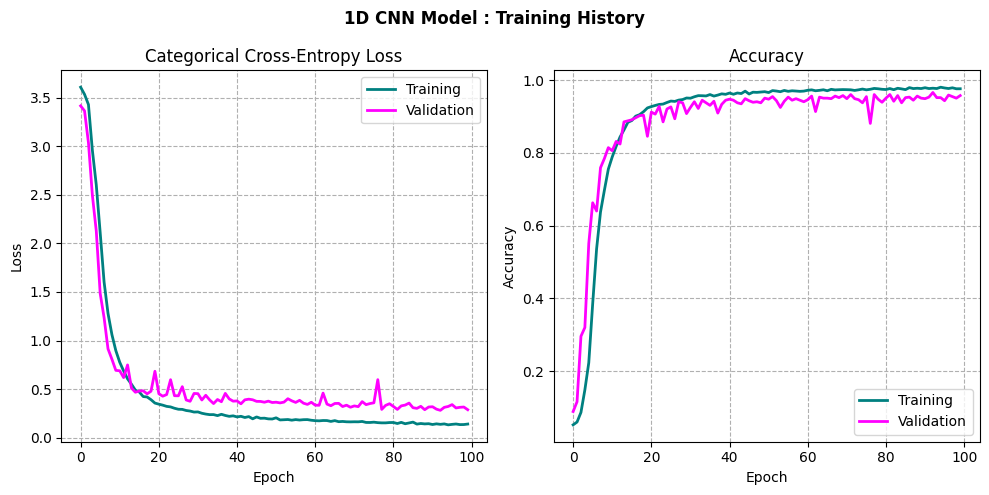

In [ ]:
#1. Plot Training Histor
plot_training_history(history_1DCNN,fileNamePLT='finDengue')

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step


<Figure size 1000x500 with 0 Axes>

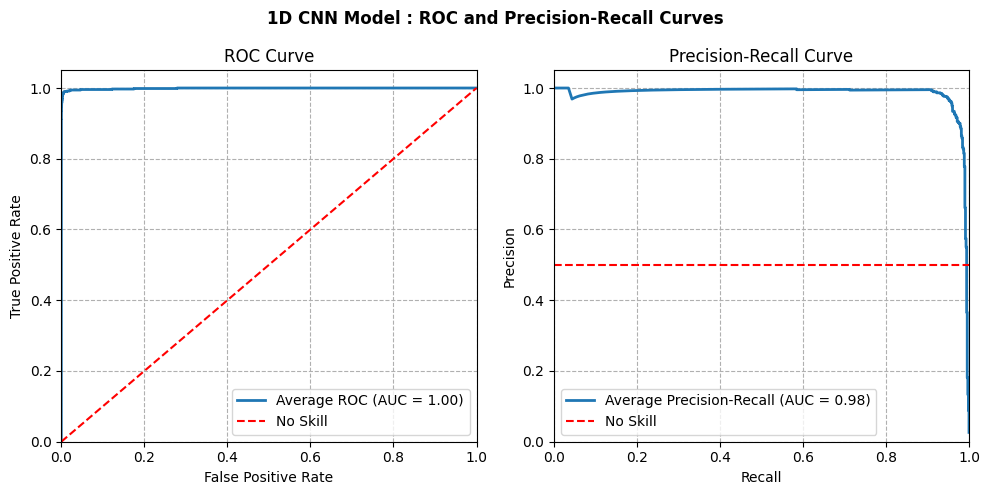

In [ ]:
#2. Plot ROC and Precision-Recall Curves
y_scores = model.predict(x_test)  # Predictions
plot_ROC_and_PR(y_test, y_scores, lineages, fileNamePLT="finDengue_CNN")

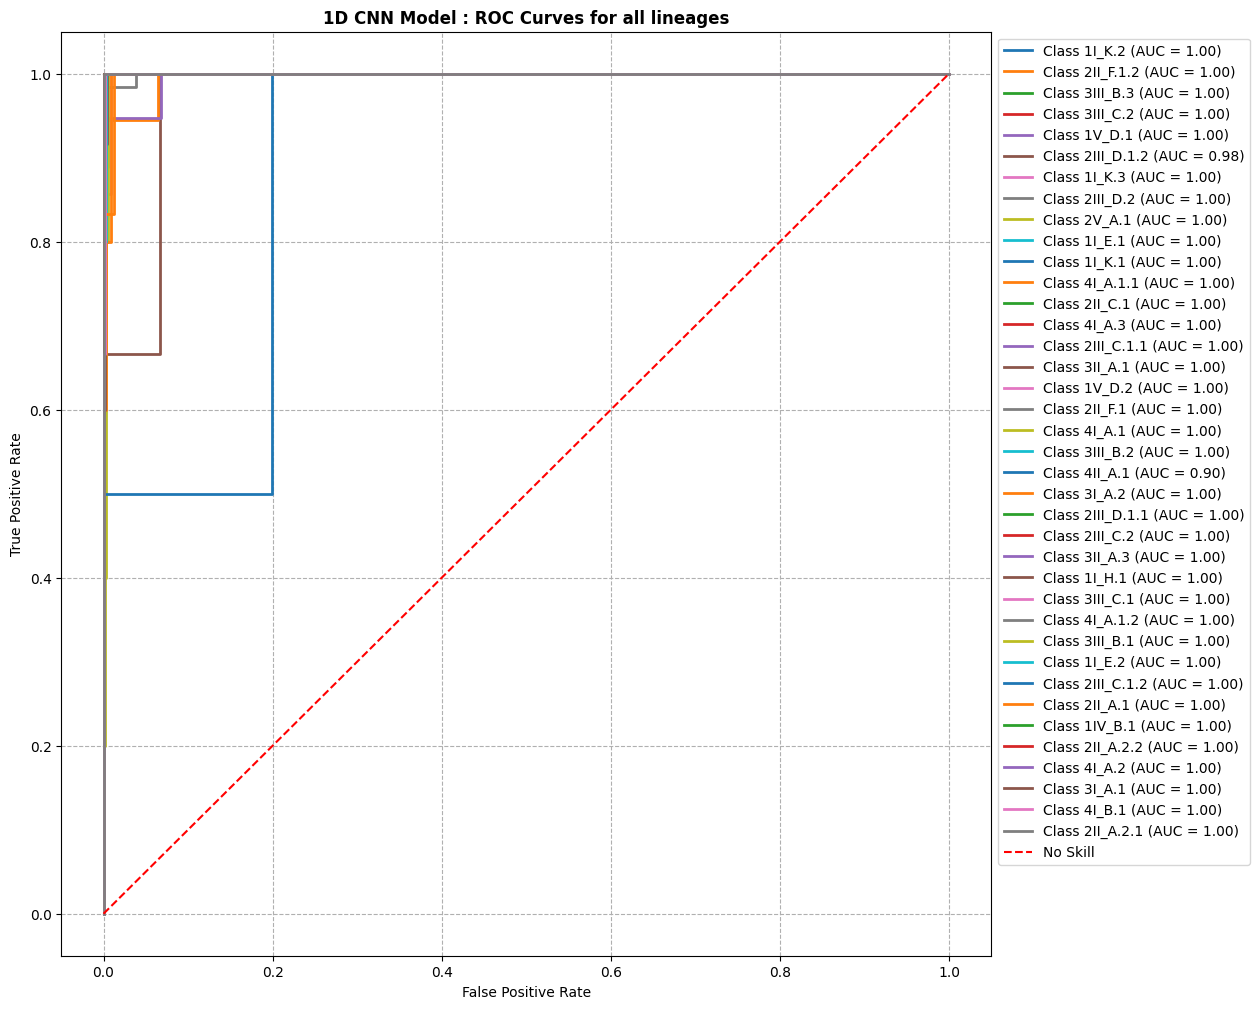

In [ ]:
plot_ROC_all_classes(y_test, y_scores, lineages, fileNamePLT="finDengue_CNN_Multiclass")

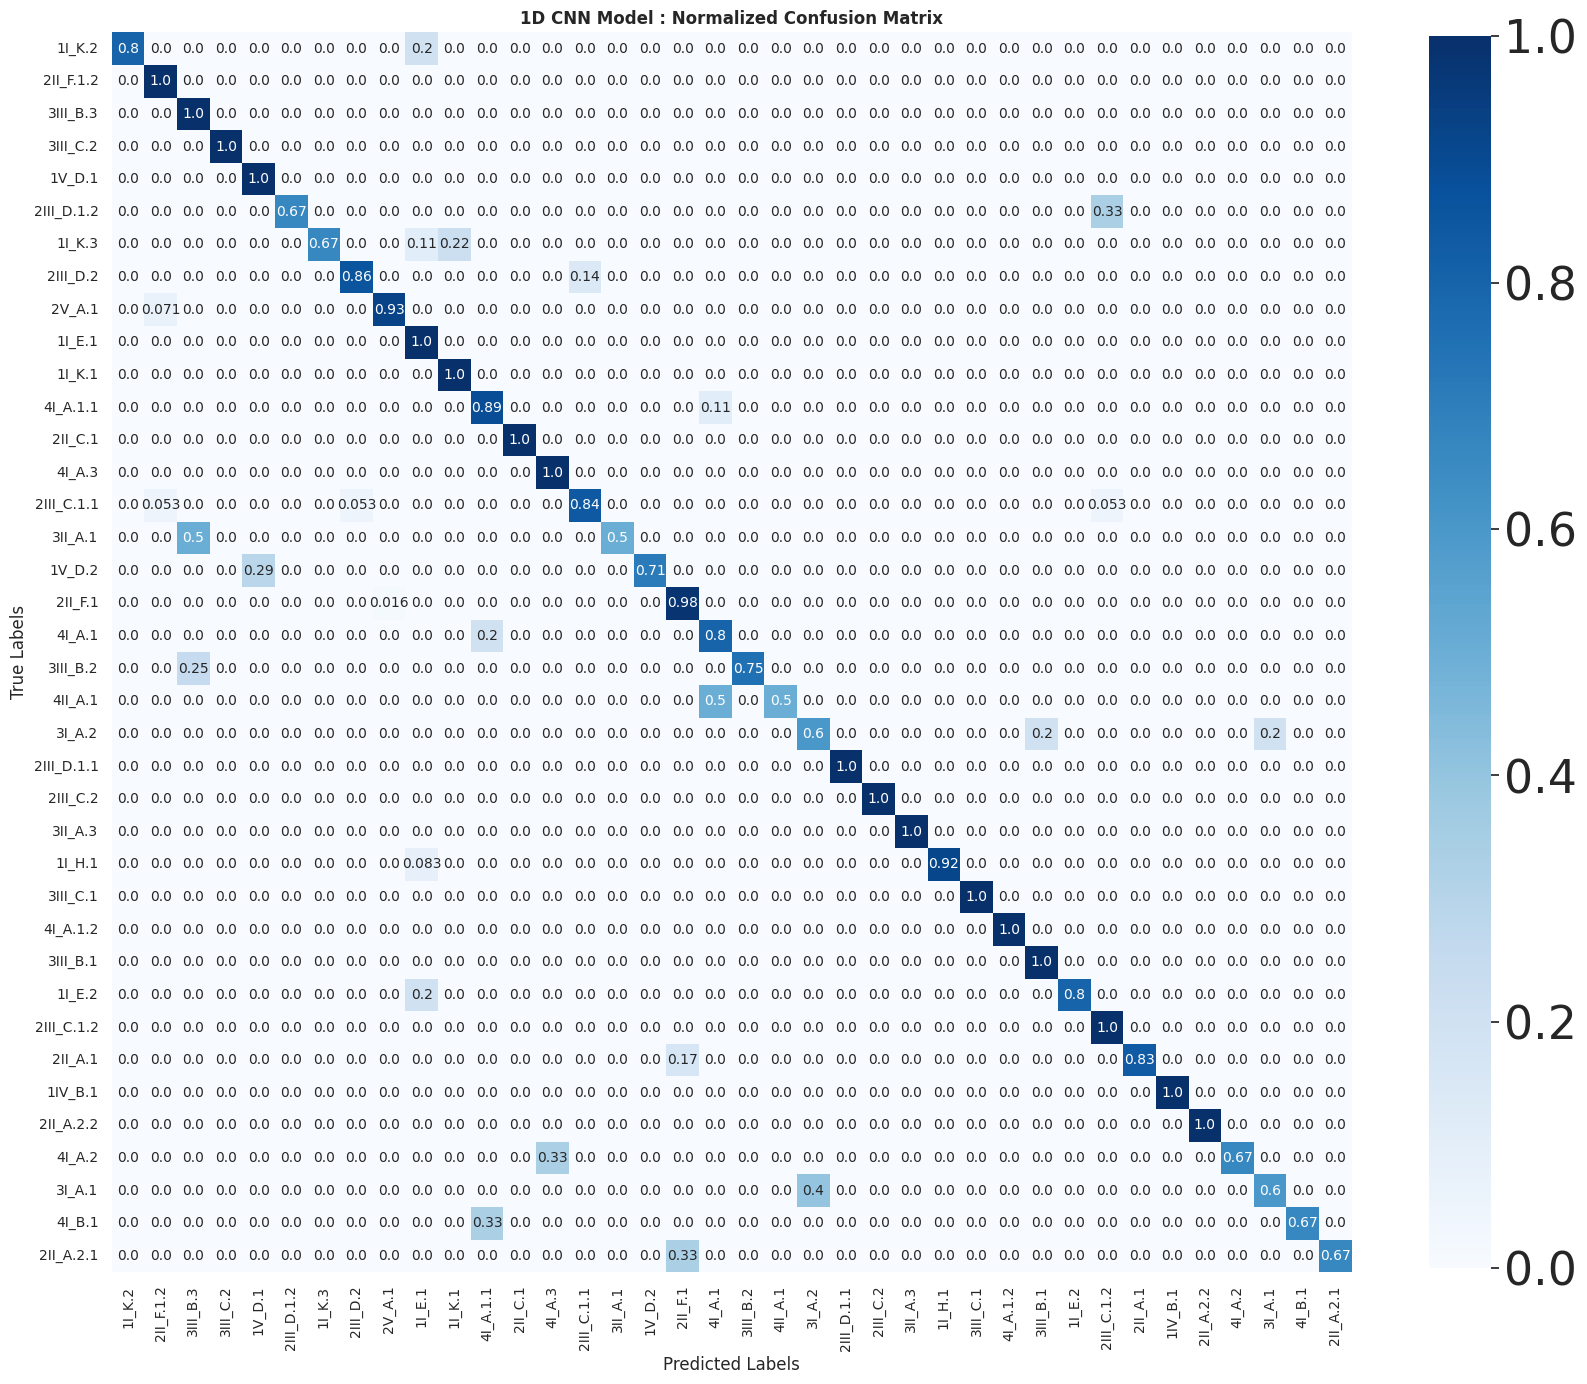

In [ ]:
plot_confusion_matrix(y_test, y_scores, lineages, fileNamePLT="finDengue_CNN_CM")

# `4.2. 2D CNN With FCGR-32`

In [ ]:
# 1. Model History (loss + accuracy)
def plot_training_history(model, fileNamePLT, figsize=(10, 5)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('2D CNN Model : Training History', fontweight='bold')

    # Plot loss
    ax1.plot(model.history['loss'], linewidth=2,alpha=1, color='teal', label='Training')
    ax1.plot(model.history['val_loss'],  linewidth=2,alpha=1, color='magenta', label='Validation')
    ax1.set_title('Categorical Cross-Entropy Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper right')
    ax1.grid(linestyle='--')

    # Plot accuracy
    ax2.plot(model.history['accuracy'], linewidth=2,alpha=1, color='teal', label='Training')
    ax2.plot(model.history['val_accuracy'], linewidth=2,alpha=1, color='magenta', label='Validation')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend(loc='lower right')
    ax2.grid(linestyle='--')

    plt.tight_layout()
    fileNamePLT = "/content/FINAL_DATASET/MODELS/2DCNN_FCGR/" + fileNamePLT + "32_Training_cnn.pdf"
    plt.savefig(fileNamePLT)
    plt.show()

In [ ]:
# 2. ROC and Precision-Recall Curve for the Model
def plot_ROC_and_PR(y_test, y_scores, classNames, fileNamePLT,figsize=(10,5)):
    n_classes = len(classNames)
    fpr, tpr, roc_auc = {}, {}, {}
    precision, recall, pr_auc = {}, {}, {}

    # Compute ROC curve and Precision-Recall curve for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

        precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_scores[:, i])
        pr_auc[i] = auc(recall[i], precision[i])

    # Micro-average ROC and Precision-Recall
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_scores.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    precision["micro"], recall["micro"], _ = precision_recall_curve(y_test.ravel(), y_scores.ravel())
    pr_auc["micro"] = auc(recall["micro"], precision["micro"])

    # Plot ROC curve
    plt.figure(figsize=figsize)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('2D CNN Model : ROC and Precision-Recall Curves', fontweight='bold')

    # Plot ROC Curve
    ax1.plot(fpr["micro"], tpr["micro"], linewidth=2,alpha=1,label=f'Average ROC (AUC = {roc_auc["micro"]:.2f})')
    ax1.plot([0, 1], [0, 1], 'k--',color='red', label='No Skill')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend(loc="lower right")
    ax1.grid(linestyle='--')

    #Plot Precision-Recall curve
    ax2.plot(recall["micro"], precision["micro"],linewidth=2,alpha=1, label=f'Average Precision-Recall (AUC = {pr_auc["micro"]:.2f})')
    ax2.plot([0, 1], [0.5, 0.5], 'k--',color='red', label='No Skill')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend(loc="lower left")
    ax2.grid(linestyle='--')

    # Save and Display the figure
    plt.tight_layout()
    fileNamePLT = "/content/FINAL_DATASET/MODELS/2DCNN_FCGR/" + fileNamePLT + "32_ROC_PR_MODEL.pdf"
    plt.savefig(fileNamePLT)
    plt.show()

# 3. ROC Curve for All 38 Classes
def plot_ROC_all_classes(y_test, y_scores, classNames, fileNamePLT):
    n_classes = len(classNames)
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(12, 12))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i],alpha=1,linewidth=2, label=f'Class {classNames[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--',color='red', label='No Skill')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('2D CNN Model : ROC Curves for all lineages',fontweight='bold')
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(linestyle='--')
    #plt.tight_layout()
    plt.savefig(f"/content/FINAL_DATASET/MODELS/2DCNN_FCGR/{fileNamePLT}_32_ROC_Classes.pdf")
    plt.show()

In [ ]:
# 4. Precision-Recall Curve for All Classes
def plot_PR_all_classes(y_test, y_scores, classNames, fileNamePLT):
    n_classes = len(classNames)
    precision, recall, pr_auc = {}, {}, {}

    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_scores[:, i])
        pr_auc[i] = auc(recall[i], precision[i])

    plt.figure(figsize=(12, 12))
    for i in range(n_classes):
        plt.plot(recall[i], precision[i], alpha=1,linewidth=2, label=f'Class {classNames[i]} (AUC = {pr_auc[i]:.2f})')

    plt.plot([0, 1], [0.5, 0.5], 'k--',color='red', label='No Skill')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('2D CNN Model : Precision-Recall Curves for all lineages',fontweight='bold')
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(linestyle='--')
    #plt.tight_layout()
    plt.savefig(f"/content/FINAL_DATASET/MODELS/2DCNN_FCGR/{fileNamePLT}_32_PR_Classes.pdf")
    plt.show()

# 5. Normalized Confusion Matrix

def plot_confusion_matrix(y_test, y_scores, classNames, fileNamePLT):
    y_test = np.argmax(y_test, axis=1)
    y_scores = np.argmax(y_scores, axis=1)
    cm = confusion_matrix(y_test, y_scores, normalize='true')

    plt.figure(figsize=(20, 20))

    # Set font scale for heatmap
    sns.set(font_scale=3.0)

    # Plot the heatmap
    sns.heatmap(cm, annot=True, square=True, fmt='.2', cmap='Blues',
                annot_kws={"size": 10}, xticklabels=classNames,
                yticklabels=classNames,cbar_kws={"shrink": 0.8})  # cbar_kws={"shrink": 0.5}: Shrink the color bar size by 50%

    # Titles and labels
    plt.title('2D CNN Model : Normalized Confusion Matrix',fontsize=12,fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)

    # Rotate and adjust tick sizes
    plt.xticks(rotation=90, fontsize=10)  # Set fontsize for x-ticks
    plt.yticks(rotation=0, fontsize=10)   # Set fontsize for y-ticks

    # Save and show the figure
    plt.savefig(f"/content/FINAL_DATASET/MODELS/2DCNN_FCGR/{fileNamePLT}_32_ConfusionMatrix.pdf")
    plt.show()

In [ ]:
# Function to compute the FCGR
def fcgr(sequence, resolution=64):
    grid = np.zeros((resolution, resolution))
    x, y = 0.5, 0.5
    for nucleotide in sequence:
        if nucleotide == 'A':
            x, y = x / 2, y / 2
        elif nucleotide == 'C':
            x, y = x / 2, (y + 1) / 2
        elif nucleotide == 'G':
            x, y = (x + 1) / 2, (y + 1) / 2
        elif nucleotide == 'T':
            x, y = (x + 1) / 2, y / 2
        grid[int(x * resolution), int(y * resolution)] += 1
    return grid
# Data preprocessing with FCGR
x = []
y = []
resolution = 32  # Define the resolution for FCGR images (32x32)
lineages = df['Lineage'].unique()
lineage_to_index = {lineage: index for index, lineage in enumerate(lineages)}

for _, row in df.iterrows():
    sequence = row['Sequence']
    lineage = row['Lineage']

    # Convert the sequence to an FCGR image
    fcgr_image = fcgr(sequence, resolution)
    x.append(fcgr_image)  # Append the FCGR image
    y.append(lineage_to_index[lineage])  # Assign index to lineage

# Print original class distribution
print("Original class distribution:")
print(Counter(y))

# Save lineages
import json
lineages_list = lineages.tolist()  # Convert ndarray to list
# Save the class labels (now in list format) to a JSON file
with open('/content/FINAL_DATASET/MODELS/2DCNN_FCGR/2D_32_lineages.json', 'w') as json_file:
    json.dump(lineages_list, json_file)

# Convert lists to arrays
x = np.array(x)
y = np.array(y)

# Reshape x for CNN input: (num_samples, resolution, resolution, 1) for grayscale images
x = x.reshape(x.shape[0], resolution, resolution, 1)

# Split the data (use stratify=y to maintain the distribution of classes)
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE only on the training data
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train.reshape(x_train.shape[0], -1), y_train)

# Print resampled class distribution
print("\nResampled class distribution:")
print(Counter(y_train_resampled))

# Reshape x_train_resampled back to (num_samples, resolution, resolution, 1)
x_train_resampled = x_train_resampled.reshape(-1, resolution, resolution, 1)
x_test = x_test.reshape(-1, resolution, resolution, 1)

# Convert labels back to categorical (one-hot encoding) after resampling
y_train_resampled = to_categorical(y_train_resampled, num_classes=len(lineages))
y_test = to_categorical(y_test, num_classes=len(lineages))

Original class distribution:
Counter({4: 678, 2: 520, 9: 420, 17: 314, 1: 291, 10: 202, 14: 92, 11: 89, 33: 80, 8: 72, 25: 59, 26: 51, 12: 47, 6: 45, 23: 43, 24: 38, 7: 36, 16: 36, 30: 32, 31: 32, 0: 27, 28: 27, 29: 27, 13: 26, 21: 26, 18: 25, 35: 23, 15: 19, 19: 18, 27: 18, 5: 17, 36: 16, 3: 14, 22: 14, 32: 14, 34: 14, 37: 14, 20: 11})

Resampled class distribution:
Counter({2: 542, 8: 542, 17: 542, 10: 542, 25: 542, 15: 542, 4: 542, 34: 542, 11: 542, 14: 542, 26: 542, 1: 542, 9: 542, 29: 542, 5: 542, 28: 542, 30: 542, 32: 542, 0: 542, 37: 542, 20: 542, 7: 542, 33: 542, 31: 542, 21: 542, 12: 542, 18: 542, 35: 542, 19: 542, 6: 542, 36: 542, 13: 542, 16: 542, 23: 542, 3: 542, 24: 542, 22: 542, 27: 542})


In [ ]:
# Print the dataset shape
print(f'X_train.shape = {x_train_resampled.shape}')
print(f'y_train.shape = {y_train_resampled.shape}')
print(f'X_test.shape = {x_test.shape}')
print(f'y_test.shape = {y_test.shape}')

X_train.shape = (20596, 32, 32, 1)
y_train.shape = (20596, 38)
X_test.shape = (706, 32, 32, 1)
y_test.shape = (706, 38)


In [ ]:
# Print some usefull dimensions for the models:
max_length = df['Length'].max()
print(f"Max length of sequences: {max_length}")
input_shape = x_train_resampled.shape[1:]  # (max_length, 4)
print(f"Input shape: {input_shape}")
num_classes = y_train_resampled.shape[1]
print(f"Number of classes: {num_classes}")

Max length of sequences: 10821
Input shape: (32, 32, 1)
Number of classes: 38


In [ ]:
def Conv2DModel(input_shape, num_classes, seed=42):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(16, (4,4), activation = 'relu', kernel_initializer=GlorotNormal(seed=seed), kernel_regularizer=l2(0.001)),
        MaxPooling2D((2, 2)),

        Conv2D(32, (4,4), activation = 'relu', kernel_initializer=GlorotNormal(seed=seed), kernel_regularizer=l2(0.001)),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3,3), activation = 'relu', kernel_initializer=GlorotNormal(seed=seed), kernel_regularizer=l2(0.001)),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(16, activation='relu'),

        Dense(num_classes, activation='softmax')
    ])
    return model

# Initialize the model with the new input shape (32, 32, 1)
model = Conv2DModel(input_shape=input_shape, num_classes=num_classes)
model.summary()


I0000 00:00:1729676689.046739   38001 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1729676689.047146   38001 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1729676689.047445   38001 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1729676689.047706   38001 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 29, 29, 16)          │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 32)          │           8,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 1, 1, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │             646 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,678 (112.02 KB)

 Trainable params: 28,678 (112.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# @title
train = False
if train:
    model.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=0.0001),metrics=['accuracy'])
    # Early Stopping callback to restore best weights and avoid overfitting
    #early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Train the model with early stopping
    history_2D_32_CNN = model.fit(x_train_resampled, y_train_resampled,batch_size=32,epochs=100,validation_data=(x_test, y_test)
    #callbacks=[early_stopping]
    )

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(x_test, y_test)
    print(f"Test accuracy: {test_accuracy}")

    # Save the history
    with open('/content/FINAL_DATASET/MODELS/history_2D_32_CNN.json', 'w') as f:
        json.dump(history_2D_32_CNN.history, f)


    fileName = "/content/FINAL_DATASET/MODELS/2DCNN_FCGR/2DCNN_FCGR_32_Dengue.keras"
    print(fileName)
    model.save(fileName)

else:
    from tensorflow.keras.models import load_model

    model = load_model("/content/FINAL_DATASET/MODELS/2DCNN_FCGR/2DCNN_FCGR_32_Dengue.keras")
    with open('/content/FINAL_DATASET/MODELS/history_2D_32_CNN.json', 'r') as f:
        history_2D_32_CNN = json.load(f)

Epoch 1/100


I0000 00:00:1729676716.834619   38659 service.cc:146] XLA service 0x7aa7a4005f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1729676716.834661   38659 service.cc:154]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1729676716.834665   38659 service.cc:154]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2024-10-23 09:45:16.877492: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-23 09:45:17.081194: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906


 86/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0599 - loss: 3.8401

I0000 00:00:1729676718.894452   38659 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


644/644 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.0634 - loss: 3.5634 - val_accuracy: 0.1190 - val_loss: 2.8962
Epoch 2/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1242 - loss: 2.9078 - val_accuracy: 0.3640 - val_loss: 2.2704
Epoch 3/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3344 - loss: 2.2954 - val_accuracy: 0.6572 - val_loss: 1.5802
Epoch 4/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5981 - loss: 1.4832 - val_accuracy: 0.9547 - val_loss: 0.7017
Epoch 5/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9596 - loss: 0.6105 - val_accuracy: 0.9844 - val_loss: 0.3097
Epoch 6/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9955 - loss: 0.2746 - val_accuracy: 0.9943 - val_loss: 0.1932
Epoch 7/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9973 - loss: 0.1740 - val_accuracy: 0.9958 - val_loss: 0.1523
Epoch 8/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9987 - loss: 0.1312 - val_accuracy: 0.9958

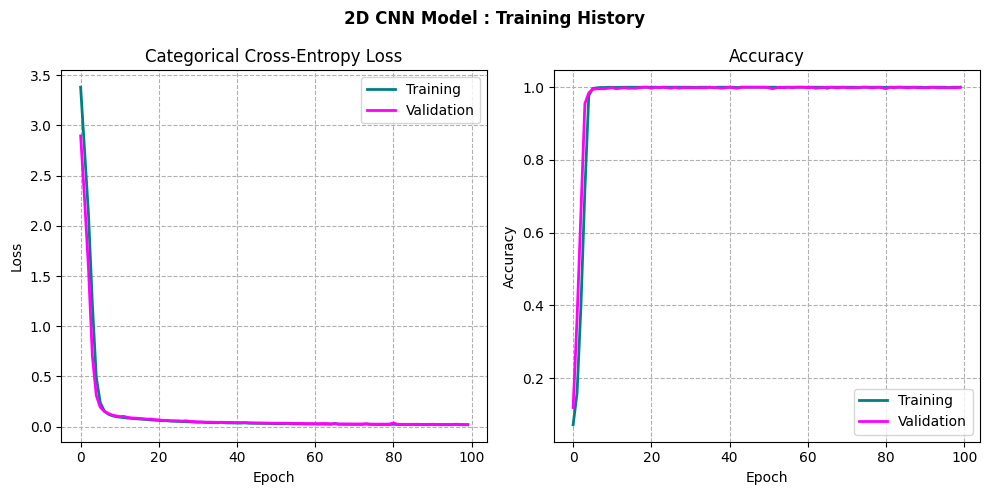

In [ ]:
#1. Plot Training Histor
plot_training_history(history_2D_32_CNN,fileNamePLT='2DDengue')

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


<Figure size 1000x500 with 0 Axes>

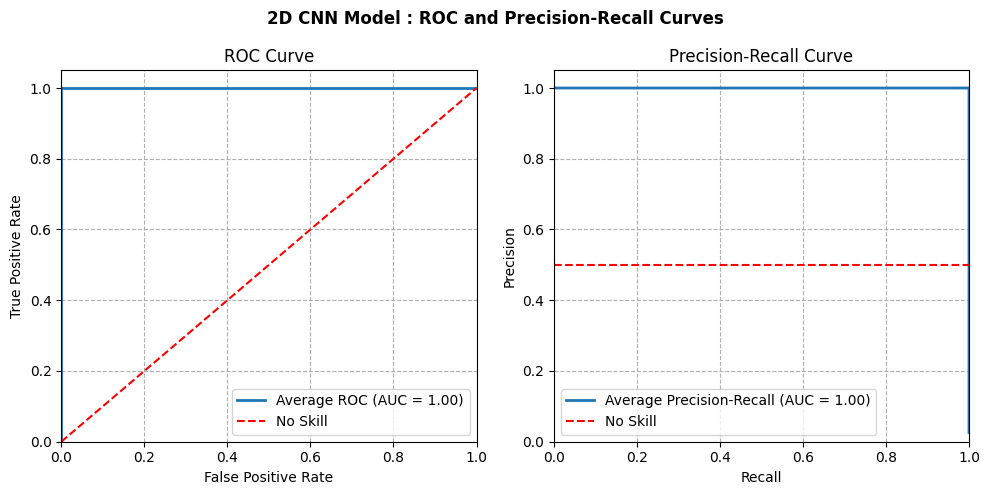

In [ ]:
#2. Plot ROC and Precision-Recall Curves
y_scores = model.predict(x_test)  # Predictions
plot_ROC_and_PR(y_test, y_scores, lineages, fileNamePLT="2DDengue_CNN")

In [ ]:
y_scores = model.predict(x_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


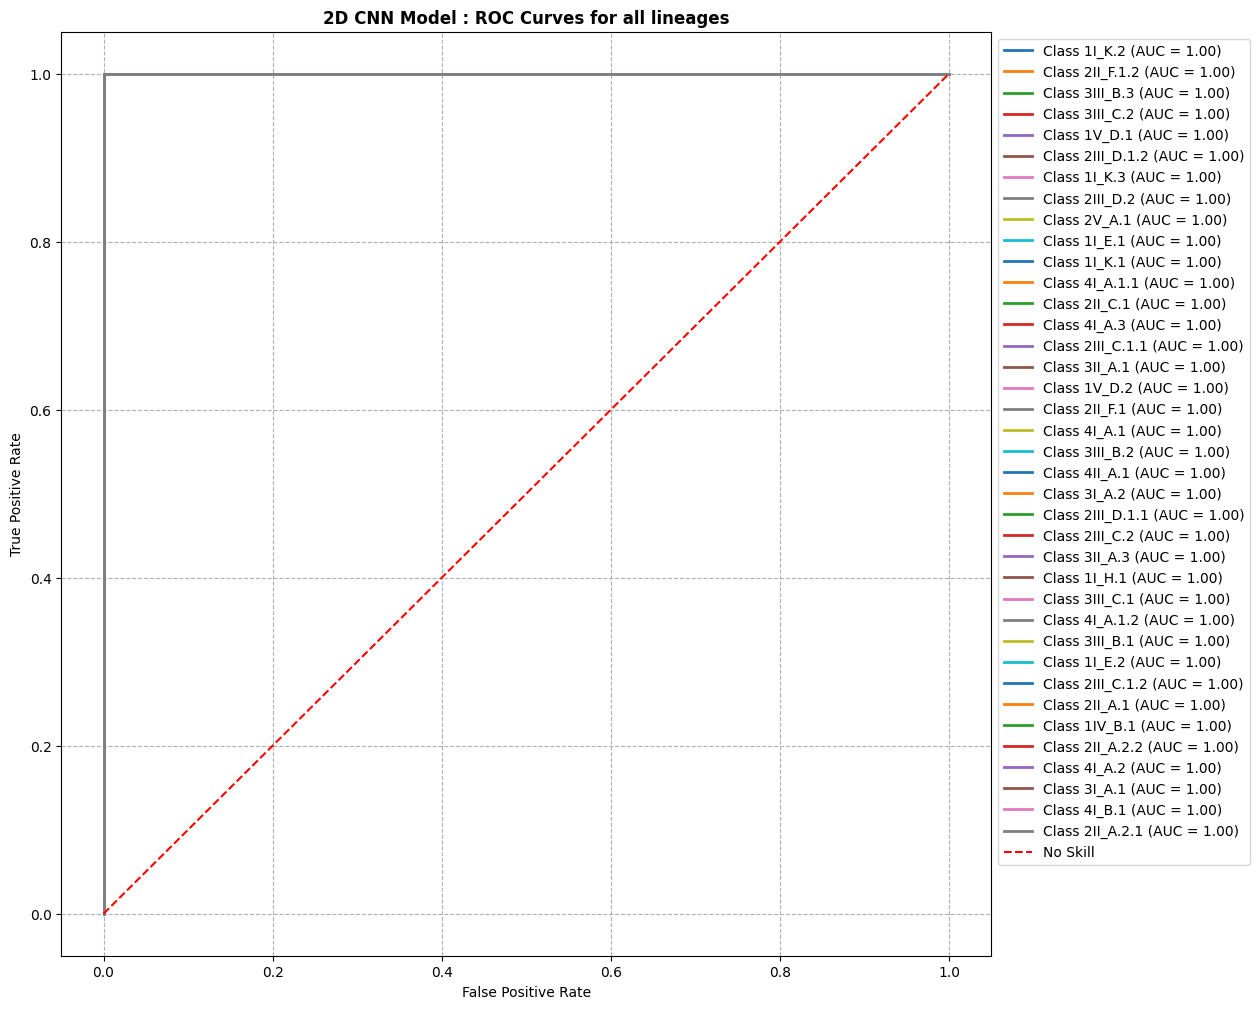

In [ ]:
plot_ROC_all_classes(y_test, y_scores, lineages, fileNamePLT="2DDengue_CNN_Multiclass")

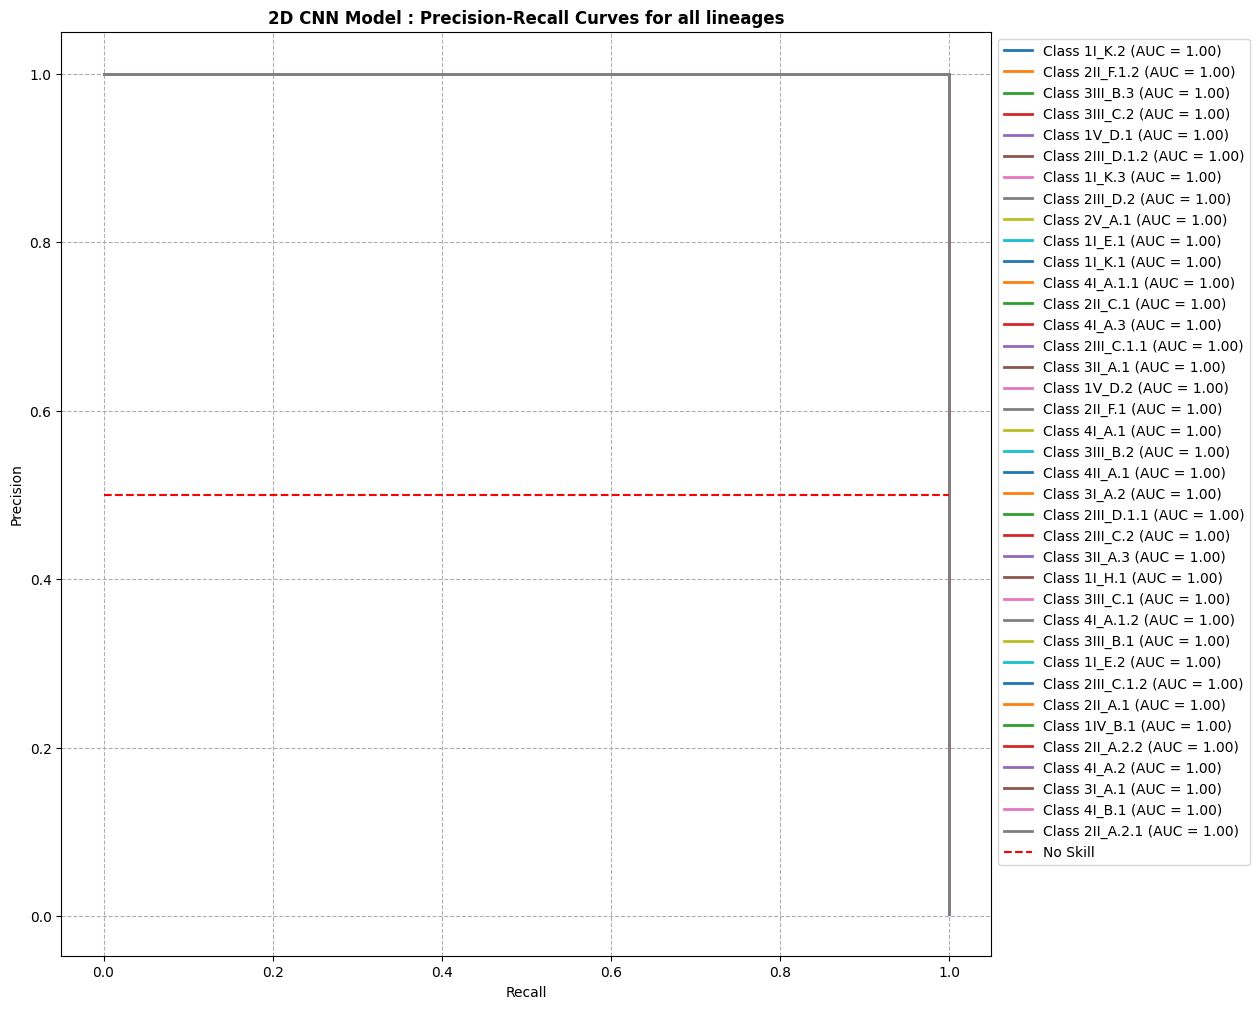

In [ ]:
plot_PR_all_classes(y_test, y_scores, lineages, fileNamePLT="2DDengue_CNN_Multiclass_PR")

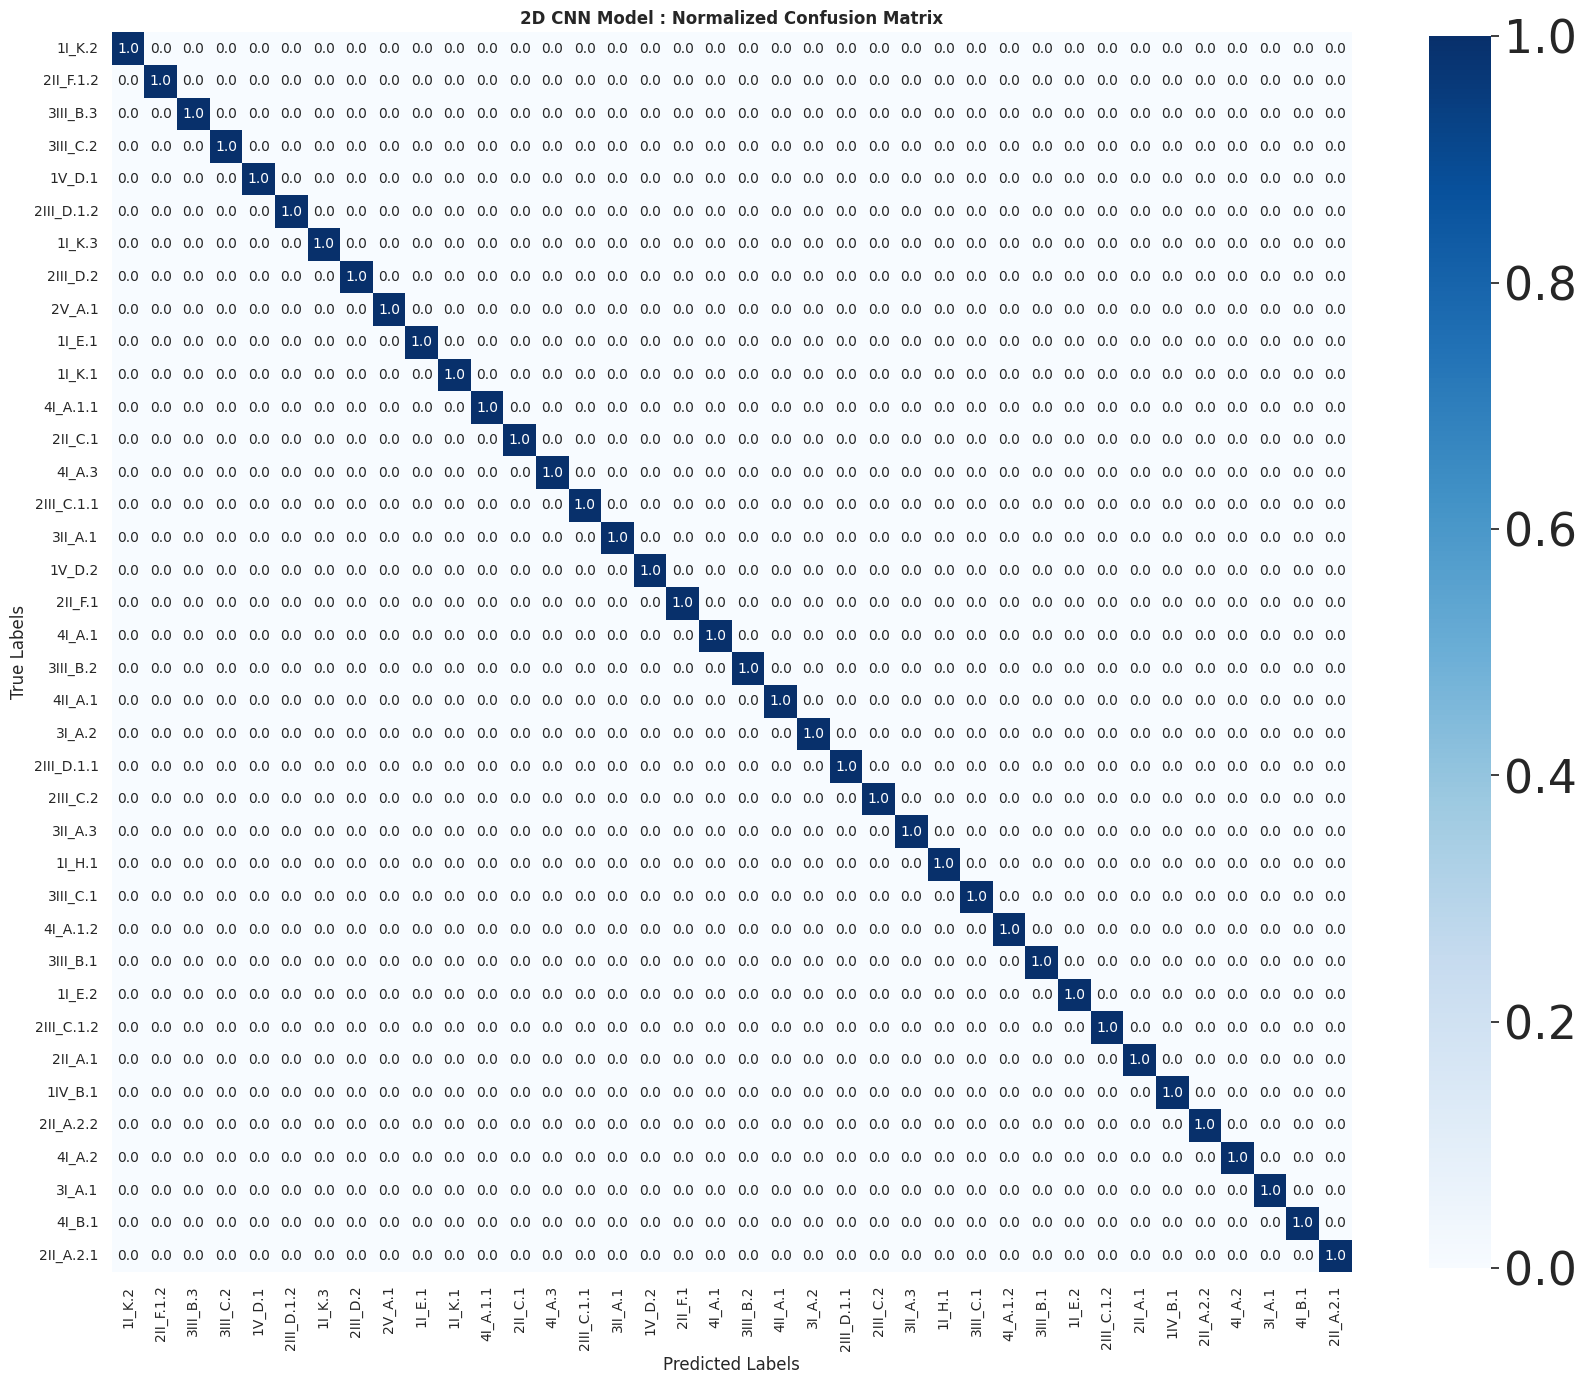

In [ ]:
plot_confusion_matrix(y_test, y_scores, lineages, fileNamePLT="2DDengue_CNN_CM")

# `Appendix`

# **BILSTM**

In [ ]:
def one_hot_encode(sequence, max_length):
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}
    encoded = [mapping.get(nucleotide, [0,0,0,0]) for nucleotide in sequence]
    padded = encoded + [[0,0,0,0]] * (max_length - len(encoded))
    return np.array(padded)

# Your dataset and sequence processing
x = []
y = []
lineages = df['Lineage'].unique()
lineage_to_index = {lineage: index for index, lineage in enumerate(lineages)}

max_length = df['Length'].max()

for _, row in df.iterrows():
    sequence = row['Sequence']
    lineage = row['Lineage']

    x.append(one_hot_encode(sequence, max_length))  # One-hot encoding sequences
    y.append(lineage_to_index[lineage])  # Assign index to lineage

# Convert lists to arrays
x = np.array(x)
y = np.array(y)

# Flatten x for SMOTE (num_samples, max_length*4)
x_flattened = x.reshape(x.shape[0], -1)

# Split the data (use stratify=y to maintain the distribution of classes)
x_train, x_test, y_train, y_test = train_test_split(x_flattened, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE only on the training data
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# Reshape x_train back to (num_samples, max_length, 4) after SMOTE
x_train_resampled = x_train_resampled.reshape(-1, max_length, 4)
x_test = x_test.reshape(-1, max_length, 4)  # Ensure x_test is also in the right shape

# Convert labels back to categorical (one-hot encoding) after resampling
y_train_resampled = to_categorical(y_train_resampled, num_classes=len(lineages))
y_test = to_categorical(y_test, num_classes=len(lineages))

In [ ]:
# Define the CNN + BiLSTM model
input_shape = x_train_resampled.shape[1:]  # (max_length, 4)
num_classes = y_train_resampled.shape[1]

In [ ]:
def Improved_CNN_BiLSTM_Model(input_shape, num_classes, seed=42):
    initializer = GlorotNormal(seed=seed)

    model = Sequential([
        Input(shape=input_shape),

        Conv1D(64, kernel_size=3, activation='relu', padding='same', kernel_initializer=initializer, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_initializer=initializer, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Bidirectional(LSTM(64, return_sequences=True, kernel_initializer=initializer, kernel_regularizer=l2(0.01))),
        BatchNormalization(),
        Dropout(0.4),

        Bidirectional(LSTM(128, return_sequences=False, kernel_initializer=initializer, kernel_regularizer=l2(0.01))),
        BatchNormalization(),
        Dropout(0.4),

        Dense(64, activation='relu', kernel_regularizer=l2(0.01), kernel_initializer=initializer),
        BatchNormalization(),
        Dropout(0.5),

        Dense(num_classes, activation='softmax', kernel_initializer=initializer)
    ])

    return model

In [ ]:
# Initialize the model
model = Improved_CNN_BiLSTM_Model(input_shape=input_shape, num_classes=num_classes)

# Print the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 10821, 64)           │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 10821, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 5410, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 5410, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 5410, 128)           │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 5410, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 2705, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 2705, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 2705, 128)           │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 2705, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 2705, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 256)                 │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 38)                  │           2,470 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 408,998 (1.56 MB)

 Trainable params: 407,718 (1.56 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
# Compile the model with a lower learning rate
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model
history_bilstm = model.fit(
    x_train_resampled, y_train_resampled,
    batch_size=32,
    epochs=100,
    validation_data=(x_test, y_test)
)

Epoch 1/100


2024-10-11 08:27:46.489621: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
W0000 00:00:1728635266.822617    1226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635266.922101    1226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635266.924073    1226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635266.925981    1226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635266.928329    1226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635266.930242    1226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635266.932425    1226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635266.935001    1226 gpu_t

  1/644 ━━━━━━━━━━━━━━━━━━━━ 1:38:34 9s/step - accuracy: 0.0625 - loss: 13.7341

W0000 00:00:1728635270.150545    1228 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.1393 - loss: 10.2669

...

644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.1395 - loss: 10.2627

W0000 00:00:1728635507.393152    1228 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635507.411106    1228 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635507.414107    1228 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635507.416150    1228 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635507.418686    1228 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635507.423025    1228 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635507.426441    1228 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635507.429345    1228 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635507.434196    1228 gp

644/644 ━━━━━━━━━━━━━━━━━━━━ 251s 376ms/step - accuracy: 0.1396 - loss: 10.2585 - val_accuracy: 0.4221 - val_loss: 3.7441
Epoch 2/100


W0000 00:00:1728635511.760964    1224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635511.761727    1224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635511.762439    1224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635511.763174    1224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635511.763882    1224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635511.764592    1224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635511.765285    1224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635511.766026    1224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1728635511.766752    1224 gp

644/644 ━━━━━━━━━━━━━━━━━━━━ 242s 376ms/step - accuracy: 0.4632 - loss: 3.2771 - val_accuracy: 0.7096 - val_loss: 1.8710
Epoch 3/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 242s 376ms/step - accuracy: 0.6351 - loss: 1.9168 - val_accuracy: 0.7436 - val_loss: 1.5867
Epoch 4/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 243s 377ms/step - accuracy: 0.7315 - loss: 1.5308 - val_accuracy: 0.7394 - val_loss: 1.5118
Epoch 5/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 243s 378ms/step - accuracy: 0.7650 - loss: 1.4115 - val_accuracy: 0.7521 - val_loss: 1.5027
Epoch 6/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 243s 377ms/step - accuracy: 0.7794 - loss: 1.3948 - val_accuracy: 0.7479 - val_loss: 1.5529
Epoch 7/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 243s 378ms/step - accuracy: 0.8018 - loss: 1.2403 - val_accuracy: 0.7918 - val_loss: 1.3284
Epoch 8/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 243s 378ms/step - accuracy: 0.8186 - loss: 1.2231 - val_accuracy: 0.7748 - val_loss: 1.4001
Epoch 9/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 244s 378ms/step - accuracy: 0.8366 - los

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy}")